In [3]:
from utils_agroforestry import *
from shapely.geometry import Point
import geopandas as gpd
import pandas as pd

# Load agroforestry composition tables
agroforest = {
    0: pd.read_csv("/Users/szelie/data/unu/agroforestry_systems/aguacate_vegetation.csv"),
    1: pd.read_csv("/Users/szelie/data/unu/agroforestry_systems/piso_verde_vegetation.csv"),
}

# Add system_id for linking to agroforestry composition
points_data = [
    {"lon": -71.252111, "lat": 19.293583, "plot_area_m2": 4184, "system_id": 0},
    {"lon": -71.293917, "lat": 19.308333, "plot_area_m2": 8000, "system_id": 1},
]

# Create GeoDataFrame
gdf_points = gpd.GeoDataFrame(
    points_data,
    geometry=[Point(p["lon"], p["lat"]) for p in points_data],
    crs="EPSG:4326"
)

# Extract features and simulate composition
df_results = extract_features_with_composition(
    gdf=gdf_points,
    agroforest_dict=agroforest,
    raster_source="dominican_republic"
)

print(df_results)


✅ Extracted from: ESA_WorldCover_10m_2021_v200_N18W072_Map.tif, mean: 10.00
✅ Extracted from: ETH_GlobalCanopyHeight_10m_2020_N18W072_Map.tif, mean: 19.86
✅ Extracted from: 20N_080W.tif, mean: 93.00
✅ Extracted from: ESA_WorldCover_10m_2021_v200_N18W072_Map.tif, mean: 10.00
✅ Extracted from: ETH_GlobalCanopyHeight_10m_2020_N18W072_Map.tif, mean: 23.55
✅ Extracted from: 20N_080W.tif, mean: 81.33
  land_use_class  canopy_height  forest_cover        lon        lat  \
0     Tree cover      19.857143     93.000000 -71.252111  19.293583   
1     Tree cover      23.550000     81.333333 -71.293917  19.308333   

   plot_area_m2  system_id                               agroforestry_species  
0          4184          0  [{'species': 'Inga fagifolia single', 'type': ...  
1          8000          1  [{'species': 'Soymida febrifuga', 'type': '1st...  


In [5]:
df_results["geometry"] = df_results.apply(lambda row: Point(row["lon"], row["lat"]), axis=1)


In [6]:
# Run simulations for each row
simulated_results = []
for idx, row in df_results.iterrows():
    species_df = agroforest[idx]  # match by row index
    result_df = simulate_agroforestry_plot(row, row.plot_area_m2, species_df)
    if result_df is not None:
        result_df["plot_index"] = idx
        simulated_results.append(result_df)

# Combine results
agroforest_df = pd.concat(simulated_results, ignore_index=True)


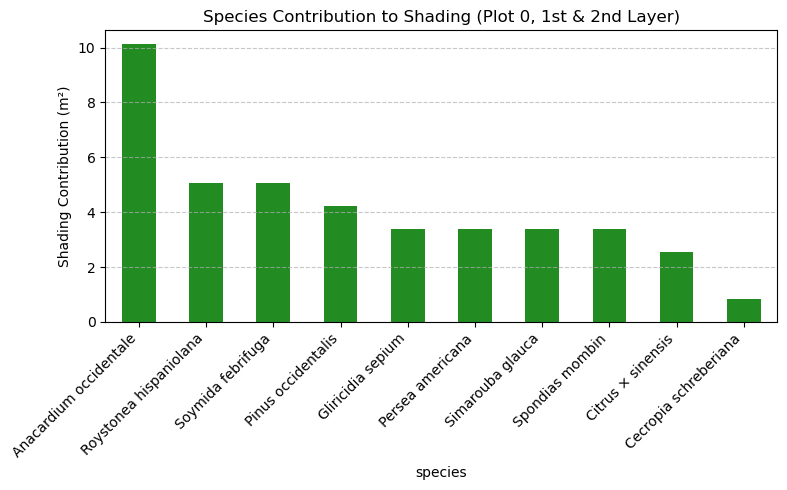

In [8]:
import matplotlib.pyplot as plt

# Filter to first and second layer trees in plot 0
subset = agroforest_df[
    (agroforest_df["plot_index"] == 1) &
    (agroforest_df["type"].isin(["1st tree", "2nd tree"]))
]

# Group by species and sum shading_m2
shading_contrib = (
    subset.groupby("species")["shading_m2"]
    .sum()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(8, 5))
shading_contrib.plot(kind="bar", color="forestgreen")
plt.ylabel("Shading Contribution (m²)")
plt.title("Species Contribution to Shading (Plot 0, 1st & 2nd Layer)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


Original value: 810.07
With +5% uncertainty: 850.57


<Axes: >

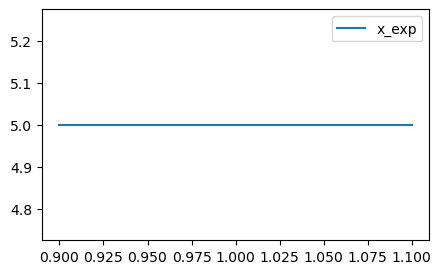

In [10]:
import scipy.stats as stats
from climada.entity import Exposures
from climada.engine.unsequa import InputVar

agroforest_df['value'] =  agroforest_df["shading_m2"]

# Create the base exposure from agroforest_df
exp_base = Exposures(data=agroforest_df[
    agroforest_df["type"].isin(["1st tree", "2nd tree"])]
)
# Define the scaling function to apply uncertainty
def exp_func(x_exp, exp_base=exp_base):
    exp = exp_base.copy()
    exp.gdf["value"] *= x_exp
    return exp

# Define uncertainty distribution: uniform ±10%
exp_distr = {"x_exp": stats.uniform(loc=0.9, scale=0.2)}  # 0.9 to 1.1
exp_iv = InputVar(exp_func, exp_distr)

# Test with x_exp = 1.05
exp_test = exp_iv.func(x_exp=1.05)
print(f"Original value: {exp_base.gdf['value'].sum():,.2f}")
print(f"With +5% uncertainty: {exp_test.gdf['value'].sum():,.2f}")

# Optional: plot the distribution
exp_iv.plot(figsize=(5, 3))


In [13]:
import os
from climada.hazard.base import Hazard
from config import DATA_DIR, TERRACLIMATE_PATHS
from utils_hazards import (
    get_aggregates, compute_spei_3,
    generate_gev_sample_field, create_hazard_from_array
)

# === Settings ===
LAT_BOUNDS_DR = (20.0, 17.5)
LON_BOUNDS_DR = (-72.0, -68.0)
haz_types = ["TM", "PR", "SPEI"]
output_dir = os.path.join(DATA_DIR, "hazards_dominican_republic")
os.makedirs(output_dir, exist_ok=True)

def get_hazard_path(scenario, haz_type):
    return os.path.join(output_dir, f"write_hazard_{scenario}_{haz_type}.hdf5")

def load_hazard_from_file(scenario, haz_type):
    path = get_hazard_path(scenario, haz_type)
    haz = Hazard()
    haz.read(path)
    print(f"📂 Loaded: {path}")
    return haz

def save_hazard_to_file(hazard, scenario, haz_type):
    path = get_hazard_path(scenario, haz_type)
    hazard.write(path)
    print(f"💾 Saved: {path}")

# === Main loop ===
hazard_dict = {}

for scenario, path in TERRACLIMATE_PATHS.items():
    print(f"\n🚀 Processing scenario: {scenario}")
    all_exist = all(os.path.exists(get_hazard_path(scenario, haz_type)) for haz_type in haz_types)

    if all_exist:
        print("✅ All hazard files found — skipping computation.")
        hazard_dict[scenario] = {
            haz_type: load_hazard_from_file(scenario, haz_type)
            for haz_type in haz_types
        }
        continue

    print("🧮 Computing hazards...")
    tmean, ppt, ppt_monthly, pet_monthly = get_aggregates(path)

    print("🌵 Computing SPEI...")
    spei_3 = compute_spei_3(ppt_monthly, pet_monthly)
    spei_yearly = spei_3.groupby(spei_3.time.dt.year).min("time")

    print("🎲 Sampling synthetic HOT, DRY, and DRIEST years (GEV)...")
    tmean_100yrs = generate_gev_sample_field(tmean, n_years=100)
    ppt_100yrs = generate_gev_sample_field(ppt, n_years=100, invert=True)
    spei_100yrs = generate_gev_sample_field(spei_yearly, n_years=100, invert=True)

    print("🌍 Creating CLIMADA Hazard objects...")
    haz_tmean = create_hazard_from_array(tmean_100yrs, haz_type="TM", units="degC")
    haz_ppt = create_hazard_from_array(ppt_100yrs, haz_type="PR", units="mm")
    haz_spei = create_hazard_from_array(spei_100yrs, haz_type="SPEI", units="index")

    # Save to disk
    save_hazard_to_file(haz_tmean, scenario, "TM")
    save_hazard_to_file(haz_ppt, scenario, "PR")
    save_hazard_to_file(haz_spei, scenario, "SPEI")

    hazard_dict[scenario] = {
        "TM": haz_tmean,
        "PR": haz_ppt,
        "SPEI": haz_spei
    }

print("\n✅ Done: HOT, DRY & DRIEST hazard generation or loading completed.")



🚀 Processing scenario: plus2C
🧮 Computing hazards...
📂 Loading 30 files for tmin
📂 Loading 30 files for tmax
📂 Loading 30 files for ppt
📂 Loading 30 files for pet


KeyboardInterrupt: 

In [12]:
import scipy.stats as stats
from climada.engine.unsequa import InputVar
from climada.entity.impact_funcs import ImpactFuncSet

# Function that returns an impact function set with uncertain temperature thresholds
def impf_func(x_thr_shift, base_df=agroforest_df.copy(), tmean=tmean, ppt=ppt):
    # Step 1: Define impact functions with shifted thresholds
    impf_temp_prec, species_to_temp_id, species_to_prec_id = define_temp_prec_impfs(
        base_df, tmean, ppt, threshold_shift=x_thr_shift  # <-- you need to add this param in your function
    )
    # Step 2: Wind (TC)
    impf_tc = define_tc_impfs()
    # Step 3: Drought
    species_df = base_df  # replace with appropriate species input if different
    spei_dict = generate_spei_dict_from_dra(species_df)
    impf_drought, species_to_drought_id = define_drought_impfs(spei_dict)

    # Step 4: Assign IDs
    df = assign_impact_function_ids(
        base_df.copy(),
        species_to_temp_id,
        species_to_prec_id,
        species_to_drought_id
    )

    # Step 5: Merge all
    impf_set = impf_temp_prec.copy()
    for impf in impf_tc + impf_drought:
        impf_set.append(impf)
    
    return impf_set

# Define the distribution for temperature threshold shift ±1°C
impf_distr = {"x_thr_shift": stats.uniform(loc=-1.0, scale=2.0)}

# Wrap in InputVar
impf_iv = InputVar(impf_func, impf_distr)

# Test with a +0.5°C shift
impf_test = impf_iv.func(x_thr_shift=0.5)
print(f"Number of impact functions with shifted thresholds: {len(impf_test)}")

# Plot uncertainty distribution
impf_iv.plot(figsize=(5, 3))


NameError: name 'hazard_dict' is not defined